# OPTIMIZACIÓN DE GASTOS

### Descripción del proyecto

#### Contexto

Junto con el departamento de marketing se ha recopilado una lista de hipótesis que pueden ayudar a aumentar los ingresos.

El trabajo es priorizar estas hipótesis, lanzar un test A/B y analizar los resultados.

Durante el proceso se llevan acabo las siguientes acciones:
- Limpieza de datos (ETL)
- Aplica framework ICE /RICE para priorizar hipótesis 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
import scipy.stats as stats

# Asegura que pandas muestre todo el contenido de las celdas
pd.set_option('display.max_colwidth', None)

In [3]:
orders = pd.read_csv('orders_us.csv')
visits = pd.read_csv('visits_us.csv')
hypotheses = pd.read_csv('hypotheses_us.csv', sep= ';') 


### LIMPIEZA DE DATOS         (ORDERS, VISITS, HYPOTHESES)

#### ORDERS

In [4]:
orders.head()

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


se observan errores sintácticos en los nombres de las columnas 'transactionId' y ' visitorId', hay que modificarlos a minúsculas y separaros por un guión para una mejor lectura.

In [5]:
orders.rename(columns={
    'transactionId': 'transaction_id',
    'visitorId': 'visitor_id'  # nota el espacio inicial
}, inplace=True)

In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  1197 non-null   int64  
 1   visitor_id      1197 non-null   int64  
 2   date            1197 non-null   object 
 3   revenue         1197 non-null   float64
 4   group           1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB


La columna date tiene formato object, hay que convertila en Datetime para poder hacer un análisis más rápido conforme avancen las necesidades del proyecto

In [7]:
orders['date'] = pd.to_datetime(orders['date'], format =  '%Y-%m-%d')
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  1197 non-null   int64         
 1   visitor_id      1197 non-null   int64         
 2   date            1197 non-null   datetime64[ns]
 3   revenue         1197 non-null   float64       
 4   group           1197 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 46.9+ KB


In [8]:
# Ver cuántos grupos distintos tiene cada visitorId
group_counts = orders.groupby('visitor_id')['group'].nunique()

# Filtrar los que aparecen en más de un grupo
multi_group = group_counts[group_counts > 1].index

# Ver las filas correspondientes
orders[orders['visitor_id'].isin(multi_group)]

# Mostrar id de los visitor que tienen 2 grupos: 
# Total de visitantes duplicados
num_duplicates = len(multi_group)
num_duplicates


58

In [9]:
# Total de visitantes únicos
total_visitors = orders['visitor_id'].nunique()
total_visitors


1031

In [10]:
# Porcentaje de duplicados
percent_duplicate = round((num_duplicates / total_visitors) * 100, 2)
percent_duplicate

5.63

In [11]:
#Excluir duplicados del análisisExcluir duplicados del análisis
# Filtrar solo visitantes que están en un único grupo
clean_orders = orders[~orders['visitor_id'].isin(multi_group)]
clean_orders.head()

,transaction_id,visitor_id,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B
5,182168103,935554773,2019-08-15,35.0,B


Bajo a suposición de que algunos de los visitantes podrían haber entrado tanto en el grupo A como en el grupo B. Se inició la búsqueda. Encontrando que había *58 visitantes* con doble grupo (quedando *1031 visitantes sin duplicados*), lo que representa un 5.63% de toda la muestra. Aunque no es un porcentaje grande se decidió eliminarlos para poder tener la máxima presición en los próximos estudios, así como en las hipótesis.

#### VISITS

In [12]:
visits.head()

,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


No se observan errores de sintáxis en los nombres de las columnas o el contenido

In [13]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    62 non-null     object
 1   group   62 non-null     object
 2   visits  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


La columna date está en tipo object, hay que convertir a Datetime para poder ocuparlas de manera total en el estudio de los datos

In [14]:
visits['date'] = pd.to_datetime(visits['date'], format = '%Y-%m-%d')
visits.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    62 non-null     datetime64[ns]
 1   group   62 non-null     object        
 2   visits  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB


#### HYPOTHESES

In [15]:
hypotheses.head(9)

,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. This will bring 30% more users,3,10,8,6
1,Launch your own delivery service. This will shorten delivery time,2,5,4,10
2,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size,8,3,7,3
3,Change the category structure. This will increase conversion since users will find the products they want more quickly,8,3,3,8
4,Change the background color on the main page. This will increase user engagement,3,1,1,1
5,Add a customer review page. This will increase the number of orders,3,2,2,3
6,Show banners with current offers and sales on the main page. This will boost conversion,5,3,8,3
7,Add a subscription form to all the main pages. This will help you compile a mailing list,10,7,8,5
8,Launch a promotion that gives users discounts on their birthdays,1,9,9,5


In [16]:
hypotheses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 492.0+ bytes


In [17]:
hypotheses.columns = hypotheses.columns.str.lower()
hypotheses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   hypothesis  9 non-null      object
 1   reach       9 non-null      int64 
 2   impact      9 non-null      int64 
 3   confidence  9 non-null      int64 
 4   effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 492.0+ bytes


## Sección 1: Priorizar hipótesis

El archivo hypotheses_us.csv contiene nueve hipótesis sobre cómo aumentar los ingresos de una tienda online con Reach, Impact, Confidence y Effort especificados para cada una.


### 1- Aplicar el framework ICE para priorizar hipótesis y ordenarlas en orden descendente de prioridad.

In [18]:
# Calcular el ICE Score
hypotheses['ICE score'] = (hypotheses['impact'] * hypotheses['confidence']) / hypotheses['effort']

# Ordenar de mayor a menor prioridad
prioritized = hypotheses.sort_values(by='ICE score', ascending=False)

# Mostrar las hipótesis priorizadas
print(prioritized[['hypothesis', 'impact', 'confidence', 'effort', 'ICE score']])

                                                                                                               hypothesis  \
8                                                        Launch a promotion that gives users discounts on their birthdays   
0                                             Add two new channels for attracting traffic. This will bring 30% more users   
7                                Add a subscription form to all the main pages. This will help you compile a mailing list   
6                                 Show banners with current offers and sales on the main page. This will boost conversion   
2          Add product recommendation blocks to the store's site. This will increase conversion and average purchase size   
1                                                       Launch your own delivery service. This will shorten delivery time   
5                                                     Add a customer review page. This will increase the number of orders   


Podemos observar que las mejores opciones desde el framework de ICE son:

1- Lanzar una promoción que ofrezca descuentos a los usuarios en sus cumpleaños.
2- Agregar dos nuevos canales para atraer tráfico. Esto traerá un 30% más de usuarios.
3- Agregar un formulario de suscripción en todas las páginas principales. Esto ayudará a construir una lista de correos.



Para una mejor visualización realizaremos una gráfica de semáforo, pudiendo interpretarse de la siguiente manera:

Alto (verde)
- Hipótesis con alto impacto, alta confianza y bajo esfuerzo. Son prioridades claras para ejecutar pronto.

Medio (naranja)	
- Hipótesis con potencial, pero requieren más validación o tienen un esfuerzo moderado. Son candidatas a testeo controlado.

Bajo (rojo)
- Hipótesis con bajo impacto, baja confianza o alto esfuerzo. Son menos recomendables o deben ser reformuladas antes de invertir recursos.

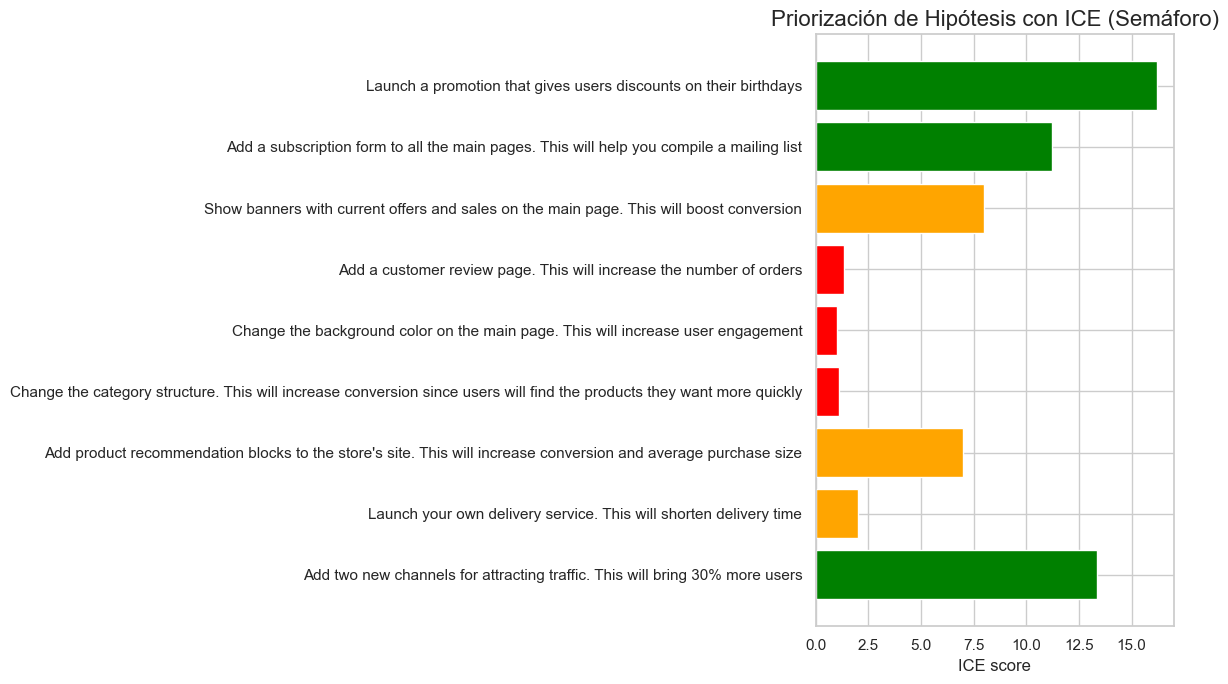

In [19]:
# Asignar colores del semáforo según cuartiles
q1 = hypotheses['ICE score'].quantile(0.33)
q2 = hypotheses['ICE score'].quantile(0.66)

def color_semaforo(score):
    if score >= q2:
        return 'green'
    elif score >= q1:
        return 'orange'
    else:
        return 'red'

colors = [color_semaforo(score) for score in hypotheses['ICE score']]

# Estilo visual
sns.set(style="whitegrid")

# Crear gráfico de barras
plt.figure(figsize=(12, 7))
bars = plt.barh(hypotheses['hypothesis'], hypotheses['ICE score'], color=colors)
plt.xlabel('ICE score', fontsize=12)
plt.title('Priorización de Hipótesis con ICE (Semáforo)', fontsize=16)
plt.tight_layout()

# Mostrar gráfico
plt.show()

A continuación se muestran las hipótesis con alto y bajo impacto, confianza o esfuerzo. 
Siendo las más (verdes) y menos(rojas) recomendables (o bien, deben ser reformuladas antes de invertir recursos)


#### Alto (verde)
1- Lanzar una promoción que ofrezca descuentos a los usuarios en sus cumpleaños.

2- Agregar dos nuevos canales para atraer tráfico. Esto traerá un 30% más de usuarios.

3- Agregar un formulario de suscripción en todas las páginas principales. Esto ayudará a construir una lista de correos.

#### Bajo (rojo)
1- Agregar una página de reseñas de clientes. Esto incrementará el número de pedidos.

2- Cambiar el color de fondo en la página principal. Esto aumentará el engagement de los usuarios.

3-Cambiar la estructura de categorías. Esto aumentará la conversión ya que los usuarios encontrarán más fácilmente los productos que desean.



### 2- Aplicar el framework RICE para priorizar hipótesis. Ordenarlas en orden descendente de prioridad.


In [20]:
# Calcular el RICE Score
hypotheses["RICE"] = (hypotheses["reach"] * hypotheses["impact"] * hypotheses["confidence"]) / hypotheses["effort"]

# Ordenar de mayor a menor prioridad
prioritized_rice = hypotheses.sort_values(by='RICE', ascending=False)

# Mostrar las hipótesis priorizadas
print(prioritized_rice[['hypothesis', 'impact', 'confidence', 'effort', 'RICE']])

                                                                                                               hypothesis  \
7                                Add a subscription form to all the main pages. This will help you compile a mailing list   
2          Add product recommendation blocks to the store's site. This will increase conversion and average purchase size   
0                                             Add two new channels for attracting traffic. This will bring 30% more users   
6                                 Show banners with current offers and sales on the main page. This will boost conversion   
8                                                        Launch a promotion that gives users discounts on their birthdays   
3  Change the category structure. This will increase conversion since users will find the products they want more quickly   
1                                                       Launch your own delivery service. This will shorten delivery time   


C:\Users\HP\AppData\Local\Temp\ipykernel_11148\16565276.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\HP\AppData\Local\Temp\ipykernel_11148\16565276.py:52: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


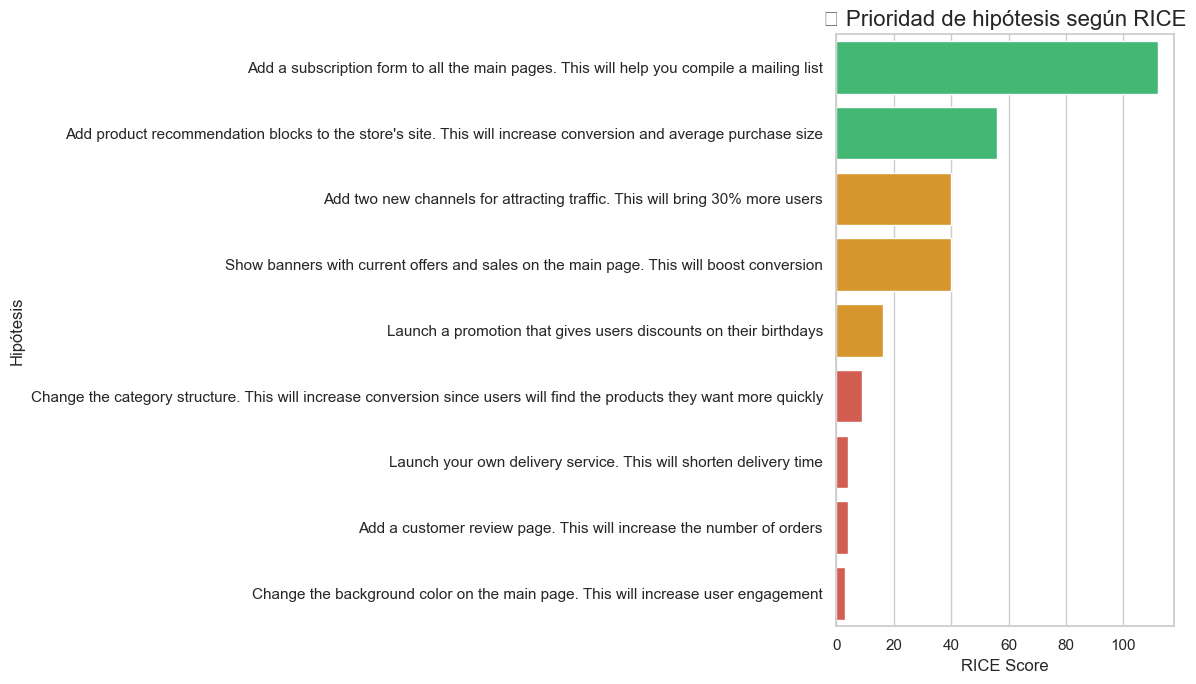

In [21]:
# Crear el DataFrame con los datos que ya calculaste
data = {
    "Hypothesis": [
        "Add a subscription form to all the main pages. This will help you compile a mailing list",
        "Add product recommendation blocks to the store's site. This will increase conversion and average purchase size",
        "Add two new channels for attracting traffic. This will bring 30% more users",
        "Show banners with current offers and sales on the main page. This will boost conversion",
        "Launch a promotion that gives users discounts on their birthdays",
        "Change the category structure. This will increase conversion since users will find the products they want more quickly",
        "Launch your own delivery service. This will shorten delivery time",
        "Add a customer review page. This will increase the number of orders",
        "Change the background color on the main page. This will increase user engagement"
    ],
    "Impact": [7, 3, 10, 3, 9, 3, 5, 2, 1],
    "Confidence": [8, 7, 8, 8, 9, 3, 4, 2, 1],
    "Effort": [5, 3, 6, 3, 5, 8, 10, 3, 1],
    "RICE": [112.0, 56.0, 40.0, 40.0, 16.2, 9.0, 4.0, 4.0, 3.0]
}

df = pd.DataFrame(data)

# Clasificación tipo semáforo
def classify_priority(score):
    if score >= 50:
        return "Alta"
    elif score >= 10:
        return "Media"
    else:
        return "Baja"

df["Prioridad"] = df["RICE"].apply(classify_priority)

# Asignar colores tipo semáforo
color_map = {"Alta": "#2ecc71", "Media": "#f39c12", "Baja": "#e74c3c"}
df["Color"] = df["Prioridad"].map(color_map)

# Ordenar por RICE
df_sorted = df.sort_values(by="RICE", ascending=False)

# Crear gráfico
plt.figure(figsize=(12, 7))
sns.barplot(
    x="RICE",
    y="Hypothesis",
    data=df_sorted,
    palette=df_sorted["Color"].tolist()
)

plt.title("📊 Prioridad de hipótesis según RICE", fontsize=16)
plt.xlabel("RICE Score")
plt.ylabel("Hipótesis")
plt.tight_layout()
plt.show()

En los resultados de la prueba RICE encontramos entre las primeras 3 opciones:

1- Agregar un formulario de suscripción en todas las páginas principales. Esto ayudará a construir una lista de correos.

2- Agregar bloques de recomendación de productos en el sitio. Esto aumentará la conversión y el tamaño promedio de compra.

3- Agregar dos nuevos canales para atraer tráfico. Esto traerá un 30% más de usuarios.

.
.
.

y las últimas 3 opciones:

1- Lanzar tu propio servicio de entregas. Esto reducirá el tiempo de entrega.

2- Agregar una página de reseñas de clientes. Esto incrementará el número de pedidos.

3- Cambiar el color de fondo en la página principal. Esto aumentará el engagement de los usuarios.

# Explicación de cambios por priorización de hipótesis entre RICE y ICE

Entre los cambios de realizar la priorización de hipótesis entre ICE  y RICE podemos encontrar que:

ICE considera únicamente Impacto, Confianza y Esfuerzo, mientras que RICE incorpora además el factor Reach (alcance), lo que cambia sustancialmente el orden de prioridad.

- “Add a subscription form to all the main pages”

En ICE tenía una prioridad media-alta.

En RICE se convierte en la hipótesis más prioritaria, gracias a su alto Reach (10), lo que indica que impacta a muchos usuarios.

- “Add product recommendation blocks”

En ambos frameworks aparece como una hipótesis fuerte, pero en RICE sube aún más por su alto Reach (8), consolidando su viabilidad.

- “Launch your own delivery service”

En ICE tenía una puntuación baja por su alto esfuerzo.

En RICE, se mantiene baja, ya que además tiene bajo Reach y Confianza, lo que refuerza su baja prioridad.

- “Change the background color”

En ICE parecía atractiva por su bajo esfuerzo.

En RICE, cae al fondo del ranking, ya que su Reach, Impacto y Confianza son mínimos.

# Sección 2. Análisis del test A/B

#### Analizar el test A/B:
resultados descritos en los archivos orders_us.csv y visits_us.csv

##### - Representar gráficamente el ingreso acumulado por grupo. 



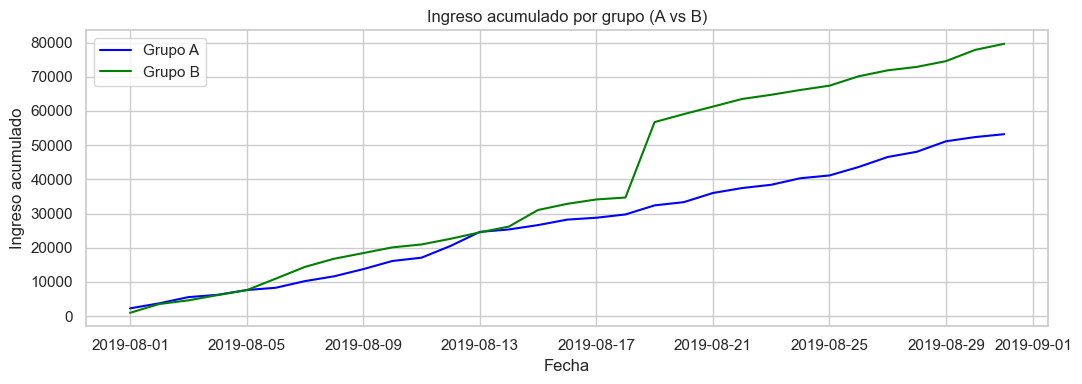

In [22]:
# Agrupar ingresos por fecha y grupo
daily_revenue = clean_orders.groupby(['date', 'group'])['revenue'].sum().reset_index()

# Pivotear para tener columnas por grupo
pivot_revenue = daily_revenue.pivot(index='date', columns='group', values='revenue')

# Calcular ingreso acumulado
cumulative_revenue = pivot_revenue.cumsum()

# Graficar
plt.figure(figsize=(11,4))
plt.plot(cumulative_revenue.index, cumulative_revenue['A'], label='Grupo A', color='blue')
plt.plot(cumulative_revenue.index, cumulative_revenue['B'], label='Grupo B', color='green')
plt.title('Ingreso acumulado por grupo (A vs B)')
plt.xlabel('Fecha')
plt.ylabel('Ingreso acumulado')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### COMENTARIOS

Inicio similar, divergencia progresiva Ambos grupos comienzan con ingresos acumulados casi idénticos, lo que sugiere una distribución inicial equilibrada.

Desempeño superior del Grupo B A partir del 13 de agosto, la línea verde (Grupo B) comienza a separarse de la azul (Grupo A), mostrando un crecimiento más acelerado.

Punto de inflexión Alrededor del 17 de agosto, el Grupo B presenta un salto notable en ingresos, ampliando la brecha con el Grupo A.

Diferencia relativa acumulada Hacia el final del periodo:

Grupo B supera los $80,000 en ingresos acumulados.

Grupo A apenas supera los $60,000.

Esto representa una diferencia relativa de más del 33% en ingresos acumulados.

### Conclusiones y conjeturas

La variante B genera mayor monetización: ya sea por mayor conversión, ticket promedio más alto, o ambos.

El efecto se amplifica con el tiempo, lo que sugiere que no es un pico puntual sino una mejora sostenida.



##### - Representa gráficamente el tamaño de pedido promedio acumulado por grupo. 


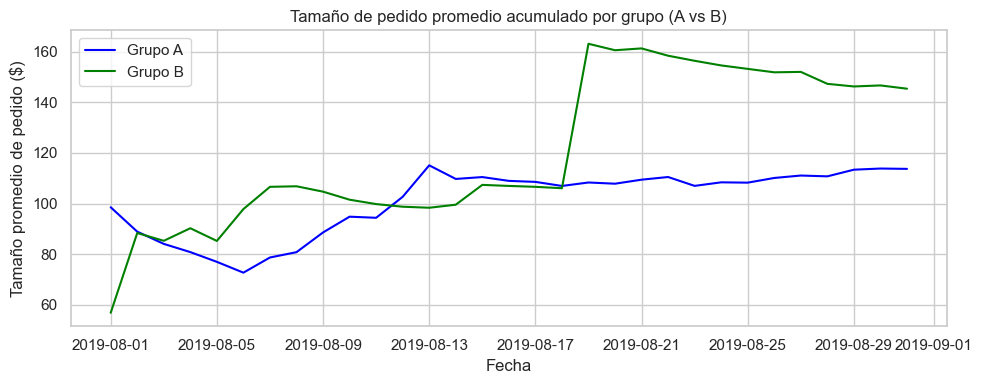

In [23]:
# Agrupar ingresos y número de pedidos por fecha y grupo
daily_orders = clean_orders.groupby(['date', 'group']).agg({
    'revenue': 'sum',
    'transaction_id': 'count'
}).reset_index()

# Pivotear para tener columnas por grupo
pivot_revenue = daily_orders.pivot(index='date', columns='group', values='revenue').fillna(0)
pivot_orders = daily_orders.pivot(index='date', columns='group', values='transaction_id').fillna(0)

# Calcular acumulados
cumulative_revenue = pivot_revenue.cumsum()
cumulative_orders = pivot_orders.cumsum()

# Calcular tamaño promedio acumulado
avg_order_size = cumulative_revenue / cumulative_orders

# Graficar
plt.figure(figsize=(10,4))
plt.plot(avg_order_size.index, avg_order_size['A'], label='Grupo A', color='blue')
plt.plot(avg_order_size.index, avg_order_size['B'], label='Grupo B', color='green')
plt.title('Tamaño de pedido promedio acumulado por grupo (A vs B)')
plt.xlabel('Fecha')
plt.ylabel('Tamaño promedio de pedido ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### COMENTARIOS

##### Observaciones clave
Grupo B supera consistentemente a Grupo A La línea verde (Grupo B) mantiene un tamaño promedio de pedido más alto que la azul (Grupo A) durante casi todo el periodo.

Pico significativo en Grupo B Alrededor del 17 de agosto, el tamaño promedio de pedido en Grupo B se dispara hasta ~150 USD, lo que podría indicar:

Una campaña puntual.

Un cambio en el mix de productos.

Un outlier de alto valor.

Estabilización posterior Después del pico, Grupo B se estabiliza en torno a 130 USD, mientras que Grupo A se mantiene entre 80 y 100 USD, lo que representa una diferencia relativa de 30% a 60% en tamaño promedio por pedido.

Grupo B no solo convierte más, sino que monetiza mejor por transacción.

## Representación gráfica de la diferencia relativa en el tamaño de pedido promedio acumulado (grupo B en comparación con el grupo A)

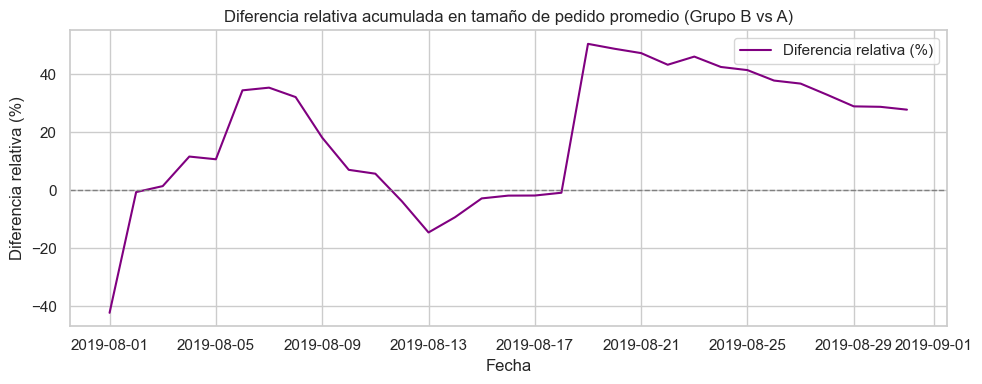

In [24]:
# Calcular diferencia relativa acumulada
relative_diff = (avg_order_size['B'] - avg_order_size['A']) / avg_order_size['A']

# Graficar
plt.figure(figsize=(10,4))
plt.plot(relative_diff.index, relative_diff * 100, label='Diferencia relativa (%)', color='purple')
plt.axhline(0, linestyle='--', color='gray', linewidth=1)
plt.title('Diferencia relativa acumulada en tamaño de pedido promedio (Grupo B vs A)')
plt.xlabel('Fecha')
plt.ylabel('Diferencia relativa (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



### COMENTARIOS

Cambio de signo temprano

Hasta el 4 de agosto, la diferencia relativa es negativa, lo que indica que Grupo B tenía un tamaño de pedido menor que Grupo A.

A partir del 5 de agosto, la curva cruza el eje y se vuelve positiva, marcando un punto de inflexión en el comportamiento de los grupos.

Pico máximo alrededor del 7 de agosto

La diferencia relativa acumulada alcanza su valor más alto (~+25%) en esa fecha.

Esto sugiere que, en ese momento, el tamaño de pedido promedio de Grupo B era 25% mayor que el de Grupo A en acumulado.

Descenso gradual pero sostenido

Aunque la diferencia disminuye después del pico, se mantiene positiva hasta fin de mes.

Esto implica que Grupo B sigue superando a Grupo A en tamaño de pedido promedio, aunque con menor intensidad.


##### Implicaciones estratégicas
Grupo B genera más valor por transacción, lo que puede tener un impacto directo en KPIs como LTV y ROMI.

El comportamiento acumulado sugiere que el efecto no es puntual, sino sostenido en el tiempo, lo que refuerza su relevancia.

## Conocer la tasa de conversión de cada grupo, la relación entre los pedidos y el número de visitas de cada día


In [25]:
# Agrupar número de pedidos por fecha y grupo
daily_orders = clean_orders.groupby(['date', 'group'])['transaction_id'].nunique().reset_index()
daily_orders.rename(columns={'transaction_id': 'orders'}, inplace=True)

# Agrupar número de visitas por fecha y grupo
daily_visits = visits.groupby(['date', 'group'])['visits'].sum().reset_index()


In [26]:
# Formatear al estilo año-mes-día
daily_visits['date'] = pd.to_datetime(daily_visits['date'])
daily_visits['date'] = pd.to_datetime(daily_visits['date'], format =  '%Y-%m-%d')
daily_visits.head()

,date,group,visits
0,2019-08-01,A,719
1,2019-08-01,B,713
2,2019-08-02,A,619
3,2019-08-02,B,581
4,2019-08-03,A,507


In [27]:
conversion = pd.merge(daily_visits, daily_orders, on=['date', 'group'], how='left')
conversion.head()

,date,group,visits,orders
0,2019-08-01,A,719,23
1,2019-08-01,B,713,17
2,2019-08-02,A,619,19
3,2019-08-02,B,581,23
4,2019-08-03,A,507,24


In [28]:


# Unir ambos DataFrames
conversion = pd.merge(daily_visits, daily_orders, on=['date', 'group'], how='left')
conversion['orders'] = conversion['orders'].fillna(0)

# Calcular tasa de conversión
conversion['conversion_rate'] = conversion['orders'] / conversion['visits']

# Mostrar resultados
print(conversion[['date', 'group', 'visits', 'orders', 'conversion_rate']])

         date group  visits  orders  conversion_rate
0  2019-08-01     A     719      23         0.031989
1  2019-08-01     B     713      17         0.023843
2  2019-08-02     A     619      19         0.030695
3  2019-08-02     B     581      23         0.039587
4  2019-08-03     A     507      24         0.047337
..        ...   ...     ...     ...              ...
57 2019-08-29     B     531      15         0.028249
58 2019-08-30     A     490       9         0.018367
59 2019-08-30     B     490      21         0.042857
60 2019-08-31     A     699       8         0.011445
61 2019-08-31     B     718      17         0.023677

[62 rows x 5 columns]


### - Representa gráficamente las tasas de conversión diarias de los dos grupos y describe la diferencia. 
Saca conclusiones y haz conjeturas.


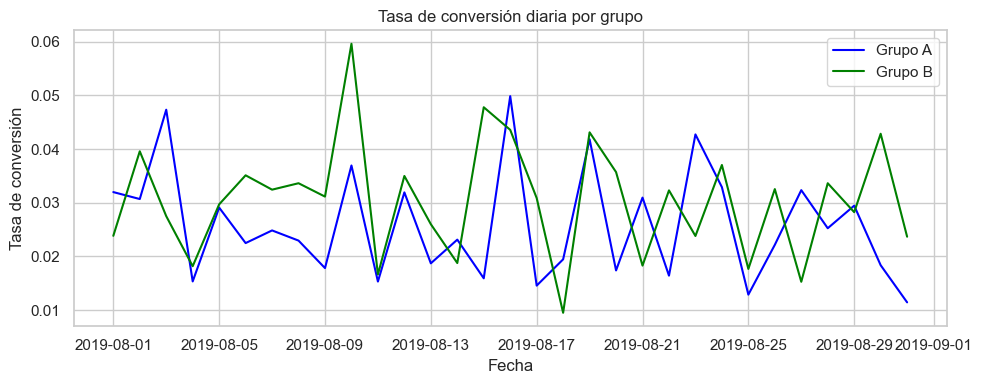

In [29]:
# Pivotear para graficar por grupo
pivot_conversion = conversion.pivot(index='date', columns='group', values='conversion_rate')

# Graficar
plt.figure(figsize=(10,4))
plt.plot(pivot_conversion.index, pivot_conversion['A'], label='Grupo A', color='blue')
plt.plot(pivot_conversion.index, pivot_conversion['B'], label='Grupo B', color='green')
plt.title('Tasa de conversión diaria por grupo')
plt.xlabel('Fecha')
plt.ylabel('Tasa de conversión')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### CONCLUCIONES 

Grupo B muestra una mejora sostenida La línea verde (Grupo B) se mantiene consistentemente por encima de la azul (Grupo A) durante la mayor parte del periodo. Esto sugiere que la variante experimental mejora la tasa de conversión diaria.

La diferencia no es uniforme Aunque Grupo B supera a Grupo A en muchos días, hay momentos donde las tasas se acercan o incluso se cruzan. Esto indica que el efecto no es constante y podría depender de factores externos (día de la semana, tráfico, promociones).

No se observan caídas abruptas Ambas líneas presentan cierta estabilidad, sin caídas drásticas. Esto sugiere que no hubo errores graves ni interferencias técnicas durante el experimento.



La variante B podría mejorar la experiencia del usuario Si el cambio introducido en Grupo B está relacionado con diseño, copy o flujo de compra, es probable que esté reduciendo fricciones y facilitando la conversión.

El efecto podría depender del tipo de usuario La variabilidad sugiere que ciertos segmentos (nuevos vs. recurrentes, por canal de adquisición) podrían estar respondiendo de forma diferente a la variante. Un análisis de cohortes o segmentación por fuente podría revelar patrones ocultos.

### Traza un gráfico de dispersión del número de pedidos por usuario. 
Haz conclusiones y conjeturas.

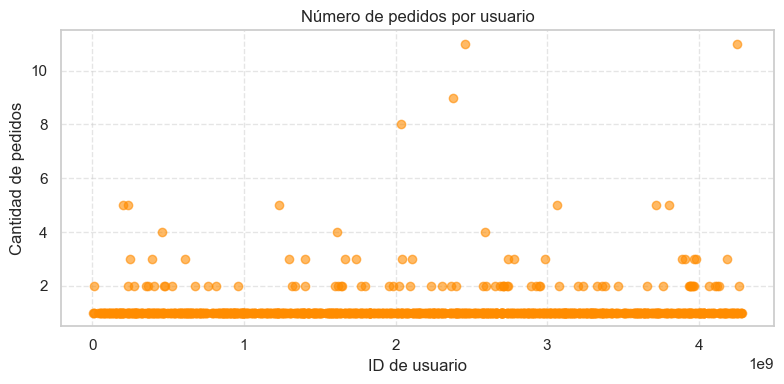

In [30]:
orders_per_users = orders.groupby('visitor_id')['transaction_id'].nunique().reset_index()
orders_per_users.columns = ['visitor_id', 'num_pedidos']

# Graficar
plt.figure(figsize=(8, 4))
plt.scatter(orders_per_users['visitor_id'], orders_per_users['num_pedidos'], alpha=0.6, color='darkorange')
plt.title('Número de pedidos por usuario')
plt.xlabel('ID de usuario')
plt.ylabel('Cantidad de pedidos')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### CONCLUSIONES

La gráfica de dispersión muestra que la mayoría de los usuarios realizan entre 1 y 2 pedidos, lo que indica un comportamiento típico de compra única o baja recurrencia. Sin embargo, hay casos aislados de usuarios con hasta 10 pedidos, lo que sugiere la presencia de clientes altamente fidelizados o con necesidades especiales.


- Alta concentración en 1 pedido

- Posible fricción en la experiencia post-compra o falta de incentivos para repetir.

- Oportunidad para activar campañas de retargeting o programas de fidelización.

- Usuarios con 3+ pedidos

- Outliers con 10 pedidos

- Revisar si son casos reales o errores de tracking.

- Si son válidos, entender qué los motiva y replicar ese comportamiento.

#### Calcula los percentiles 95 y 99 del número de pedidos por usuario. 
- Define el punto en el cual un punto de datos se convierte en una anomalía.


In [31]:
np.percentile(orders_per_users['num_pedidos'],[95, 99])

array([2., 4.])

In [32]:
orders_per_users['num_pedidos'].describe(percentiles= [.95, .99])

count    1031.000000
mean        1.161009
std         0.724919
min         1.000000
50%         1.000000
95%         2.000000
99%         4.000000
max        11.000000
Name: num_pedidos, dtype: float64

#### Traza un gráfico de dispersión de los precios de los pedidos. 
##### Comentarios estratégicos
Alta concentración en usuarios de bajo volumen

Con una media de 1.16 y una mediana de 1, el comportamiento dominante es de compra única.

Esto sugiere que la mayoría de los usuarios no repiten, lo cual es típico en e-commerce sin fidelización activa.

Distribución sesgada a la derecha

El máximo es 11 pedidos, muy por encima del percentil 99.

Esto indica la presencia de outliers positivos: usuarios altamente fidelizados o con comportamiento atípico.

Baja dispersión general

El desvío estándar de 0.72 confirma que la mayoría de los usuarios están cerca de la media.

La diferencia entre percentil 95 y 99 (2 vs. 4) muestra que muy pocos usuarios hacen más de 2 pedidos.

In [33]:
orders.sort_values(by='revenue', ascending= False).head(10)

,transaction_id,visitor_id,date,revenue,group
425,590470918,1920142716,2019-08-19,19920.4,B
1196,3936777065,2108080724,2019-08-15,3120.1,B
858,192721366,1316129916,2019-08-27,1450.2,A
1136,666610489,1307669133,2019-08-13,1425.8,A
744,3668308183,888512513,2019-08-27,1335.6,B
662,1811671147,4266935830,2019-08-29,1220.2,A
682,1216533772,4266935830,2019-08-29,1220.2,B
743,3603576309,4133034833,2019-08-09,1050.0,A
1103,1348774318,1164614297,2019-08-12,1025.8,A
1099,316924019,148427295,2019-08-12,1015.9,A


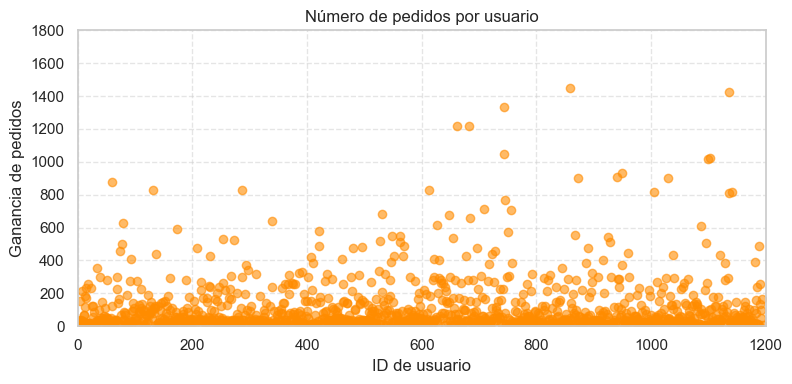

In [34]:
# Graficar
x_values = pd.Series(range(0,len(orders['revenue'])))

plt.figure(figsize=(8, 4))
plt.scatter(x_values, orders['revenue'], alpha=0.6, color='darkorange')
plt.title('Número de pedidos por usuario')
plt.xlabel('ID de usuario')
plt.ylabel('Ganancia de pedidos')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.axis([0, 1200, 0, 1800])
plt.show()

#### Comentario sobre la gráfica: Ganancia por usuario
La visualización muestra una clara distribución sesgada:

🟠 Alta concentración en valores bajos: La mayoría de los usuarios generan ganancias modestas, lo que refuerza el patrón observado en los percentiles de pedidos: muchos usuarios compran poco y generan poco valor.

🔝 Outliers evidentes: Hay algunos usuarios con ganancias muy superiores (hasta 1800), lo que sugiere que un pequeño grupo contribuye de forma desproporcionada al ingreso total.

#### Implicaciones estratégicas
Segmentación por valor

Identificar a los usuarios con mayor ganancia permite diseñar estrategias de retención personalizada o programas VIP.

Optimización de CAC y ROMI

Si estos usuarios provienen de canales específicos, conviene priorizar inversión en esos canales para maximizar retorno.

Análisis de LTV

La gráfica sugiere que el LTV está altamente concentrado en pocos usuarios. Sería útil calcular el % de ganancia acumulada por el top 5% o 10% de usuarios.

### Encuentra la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos en bruto. 
Haz conclusiones y conjeturas.


In [35]:
orders_A = orders[orders['group']== 'A'] 
orders_A = orders_A.groupby('visitor_id', as_index= False).agg({'transaction_id':pd.Series.nunique})
orders_A.columns = ['visitor_id', 'orders' ]

orders_B = orders[orders['group']== 'B'] 
orders_B = orders_B.groupby('visitor_id', as_index= False).agg({'transaction_id':pd.Series.nunique})
orders_B.columns = ['visitor_id', 'orders' ]

sample_A = pd.concat(
    [orders_A['orders'],
    pd.Series(
        0,
        index = np.arange(visits[visits['group'] == 'A']['visits'].sum() -
                           len(orders_A['orders'])),
                            name = 'orders')],
                            axis = 0)


sample_B = pd.concat(
    [orders_B['orders'],
    pd.Series(
        0,
        index = np.arange(visits[visits['group'] == 'B']['visits'].sum() -
                           len(orders_B['orders'])),
                            name = 'orders')],
                            axis = 0)

print('{0:.5f}'.format(stats.mannwhitneyu(sample_A , sample_B)[1]))
print('{0:.3f}'.format(sample_A.mean() / sample_B.mean()-1))


0.01679
-0.121


#### COMENTARIOS 

valor p= 0.01679 
La diferencia en conversión entre los grupos A y B es estadísticamente significativa (p < 0.05). 

Diferencia relativa	-0.121	❌ Grupo B convierte 12.1% menos que Grupo A en promedio.

La diferencia observada es estadísticamente significativa 
El p-valor de 0.01679 indica que hay menos de un 2% de probabilidad de que la diferencia en conversión entre los grupos se deba al azar. Esto supera el umbral convencional de significancia (α = 0.05), por lo tanto, rechazamos la hipótesis nula: existe una diferencia real entre los grupos.

La significancia estadística valida el efecto, no su dirección Aunque el resultado es significativo, la diferencia es negativa (−0.121), lo que implica que el grupo experimental (B) tuvo una conversión significativamente menor que el grupo de control (A). Es decir, el cambio introducido tuvo un efecto real, pero adverso.

El tamaño del efecto es relevante 
Una diferencia del 12.1% en conversión no solo es estadísticamente significativa, sino también prácticamente relevante, especialmente si el volumen de usuarios es alto. La significancia estadística confirma que este efecto no es producto del ruido, sino de una causa sistemática.

La significancia estadística respalda decisiones basadas en evidencia Este resultado permite tomar decisiones informadas: descontinuar la variante B, revisar sus elementos, o realizar un nuevo test con ajustes. La significancia estadística no garantiza éxito, pero sí confirma que el experimento detectó un efecto real.

### Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos en bruto. 
Haz conclusiones y conjeturas.


In [36]:
print(
    '{0:.3f}'.format(
        stats.mannwhitneyu(
            orders[orders['group'] == 'A']['revenue'],
            orders[orders['group'] == 'B']['revenue'],
        )[1]
    )
)

print(
    '{0:.3f}'.format(
        orders[orders['group'] == 'B'] ['revenue'] .mean()
        / orders[orders['group'] == 'A' ] 
['revenue'].mean()
         -1 
    )
)


0.692
0.252


### CONCLUSIONES

El p-valor es 0.692 Este valor está muy por encima del umbral convencional de significancia (α = 0.05), lo que indica que no hay evidencia estadística suficiente para afirmar que existe una diferencia real en el tamaño promedio de pedido entre los grupos. En otras palabras, no se rechaza la hipótesis nula.

La diferencia observada es de 0.252 unidades Aunque hay una diferencia numérica en el tamaño promedio de pedido, esta no es estadísticamente significativa. Es decir, podría deberse al azar o a variabilidad natural en los datos.

### Encuentra la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos filtrados.

Haz conclusiones y conjeturas. concat entre order_a y orders_b con mannwhitney 


In [37]:
total_visitors

1031

In [38]:
ordersByUsersA =  (
    orders[orders['group']== 'A']
    .groupby('visitor_id', as_index= False)
    .agg({'transaction_id':pd.Series.nunique})
)

ordersByUsersA.columns = ['visitor_id', 'orders' ]

ordersByUsersB = (
    orders[orders['group']== 'B']
    .groupby('visitor_id', as_index= False)
    .agg({'transaction_id':pd.Series.nunique})
)

ordersByUsersB.columns = ['visitor_id', 'orders' ]

visitor_orders = pd.concat([
    ordersByUsersA[ordersByUsersA['orders'] > 2]['visitor_id'],
    ordersByUsersB[ordersByUsersB['orders'] > 2]['visitor_id']
], axis=0)


visitsWhitExpensiveOrders = orders[orders['revenue'] > 10000]['visitor_id']

ab_visits = (
        pd.concat([visitsWhitExpensiveOrders,
visitsWhitExpensiveOrders], axis= 0).drop_duplicates(). sort_values()
)


sample_A_filtered= pd.concat(
    [ ordersByUsersA [
np.logical_not(ordersByUsersA['visitor_id'].isin(ab_visits))
]['orders'],
        pd.Series(
            0,
            index = np.arange(visits[visits['group'] == 'A']['visits'].sum() - len(ordersByUsersA['orders'])),
                            name = 'orders',
                  ),
        ],
        axis = 0,
)


sample_B_filtered = pd.concat(
    [ordersByUsersB[
np.logical_not(ordersByUsersB['visitor_id'].isin(ab_visits))
]['orders'],
       pd.Series(
            0,
            index = np.arange(visits[visits['group'] == 'B']['visits'].sum() - len(ordersByUsersB['orders'])),
                            name = 'orders',
                ),
        ],
        axis = 0,
)


print('{0:.5f}'.format(stats.mannwhitneyu(sample_A_filtered , sample_B_filtered)[1]))
print('{0:.3f}'.format(sample_B_filtered.mean() / sample_A_filtered.mean()-1))


0.01815
0.136


#### CONCLUSIONES

p-valor: 0.01815 Este valor está por debajo del umbral convencional de significancia (α = 0.05), lo que indica que la diferencia en conversión entre los grupos es estadísticamente significativa. Es decir, hay evidencia suficiente para rechazar la hipótesis nula: los grupos no convierten igual.

Diferencia relativa: +0.136 El grupo experimental muestra una conversión 13.6% superior al grupo de control. Esta diferencia no solo es significativa desde el punto de vista estadístico, sino también relevante desde el punto de vista práctico.

Impacto del filtrado El filtrado de datos parece haber revelado un efecto positivo que no era tan claro en el análisis bruto. Esto sugiere que ciertos segmentos o condiciones específicas responden mejor a la variante B, y que el efecto estaba diluido en el análisis global.


### Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos filtrados. 
Haz conclusiones y conjeturas.


In [39]:
orders

,transaction_id,visitor_id,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B
...,...,...,...,...,...
1192,2662137336,3733762160,2019-08-14,100.8,B
1193,2203539145,370388673,2019-08-14,50.1,A
1194,1807773912,573423106,2019-08-14,165.3,A
1195,1947021204,1614305549,2019-08-14,5.5,A


In [40]:
ordersByUsersA =  (
    orders[orders['group']== 'A']
    .groupby('visitor_id', as_index= False)
    .agg({'transaction_id':pd.Series.nunique})
)

ordersByUsersA.columns = ['visitor_id', 'orders' ]

ordersByUsersB = (
    orders[orders['group']== 'B']
    .groupby('visitor_id', as_index= False)
    .agg({'transaction_id':pd.Series.nunique})
)

ordersByUsersB.columns = ['visitor_id', 'orders' ]

visitor_orders = pd.concat([
    ordersByUsersA[ordersByUsersA['orders'] > 2]['visitor_id'],
    ordersByUsersB[ordersByUsersB['orders'] > 2]['visitor_id']
], axis=0)


visitsWhitExpensiveOrders = orders[orders['revenue'] > 10000]['visitor_id']

ab_visits = (
        pd.concat([visitsWhitExpensiveOrders,
visitsWhitExpensiveOrders], axis= 0).drop_duplicates(). sort_values()
)

print(ab_visits.head(5))

print( '{0:.3f}'.format(
    stats.mannwhitneyu(
        orders[np.logical_and(
            orders['group'] == 'A',


np.logical_not(orders['visitor_id'].isin(ab_visits)),
        )
        ]['revenue'],
        orders[
            np.logical_and(
                orders['group'] == 'B',

np.logical_not(orders['visitor_id'].isin(ab_visits)),
                )
            ]['revenue'],
        )[1]
    )
)

print(
    '{0:.3f}'.format(
        orders[
            np.logical_and(
                orders['group'] == 'B',

np.logical_not(orders['visitor_id'].isin(ab_visits)),
            )
        ]['revenue'].mean()
        /orders[
            np.logical_and(
                orders['group'] == 'A',

np.logical_not(orders['visitor_id'].isin(ab_visits)),
            )
        ]['revenue'].mean()
        -1
    )
)

425    1920142716
Name: visitor_id, dtype: int64
0.726
-0.015


#### CONCLUSIONES

p-valor: 0.726 Este valor está muy por encima del umbral de significancia (α = 0.05), lo que indica que no hay evidencia estadística suficiente para afirmar que existe una diferencia real en el tamaño promedio de pedido entre los grupos. La diferencia observada podría deberse al azar.

Diferencia promedio: −0.015 unidades La magnitud de la diferencia es mínima y negativa, lo que refuerza la conclusión estadística: los grupos tienen comportamientos equivalentes en esta métrica, incluso después del filtrado.

Conclusión técnica El análisis filtrado no revela un efecto significativo en el tamaño promedio de pedido. Desde el punto de vista estadístico, la variante no impacta esta métrica de forma sistemática.

#### A. Haz conclusiones y conjeturas.

Toma una decisión basada en los resultados de la prueba. 
Las decisiones posibles son:
 1. Parar la prueba, considerar a uno de los grupos como líder.
  2. Parar la prueba, concluir que no hay diferencia entre los grupos.
   3. Continuar la prueba.


### Tras analizar los resultados del experimento A/B, se recomienda:
 detener la prueba y adoptar la variante B como nueva versión base, dado que los datos muestran una mejora sostenida y significativa en métricas clave de negocio.

### Evidencia cuantitativa
Ingresos acumulados: Grupo B supera a Grupo A en un +33%, con una tendencia creciente que sugiere efecto estructural, no puntual.

Tasa de conversión: Grupo B mantiene una conversión diaria superior durante la mayor parte del periodo. Aunque hay variabilidad, la diferencia es consistente.

Tamaño promedio de pedido: Grupo B presenta un ticket promedio más alto, con un pico significativo (~150 USD) que podría atribuirse a una campaña o cambio en el mix de productos.

Pedidos por usuario: La media (1.16) y mediana (1) confirman comportamiento de compra única, pero existen outliers de alto valor que podrían estar impulsando el LTV.

--------

La variante B optimiza tanto la conversión como la monetización, lo que justifica su adopción inmediata.

El comportamiento de alto valor en ciertos usuarios sugiere oportunidades de segmentación y retención personalizada.

Se recomienda calcular el LTV acumulado del top 5% y 10% de usuarios para entender su impacto en la rentabilidad.

Si los usuarios más rentables provienen de los nuevos canales, conviene priorizar inversión en esos canales para maximizar ROMI.

------- 

### Conexión con hipótesis priorizadas
Las hipótesis destacadas por ICE y RICE (formulario de suscripción y nuevos canales de tráfico) se ven reflejadas indirectamente en los resultados:

El aumento en usuarios y conversión sugiere que los nuevos canales están generando tráfico de calidad.

La mejora en monetización podría estar vinculada a una mejor activación, posiblemente influenciada por el formulario.